# WORKSHEET 6

In [2]:
import numpy as np
import pandas as pd
dataset = pd.read_csv('Titanic-Dataset.csv')
print(dataset.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [3]:
import numpy as np
import pandas as pd
print("Before encoding:", dataset.columns)

dataset['Age'].fillna(dataset['Age'].median(), inplace=True)
dataset['Embarked'].fillna(dataset['Embarked'].mode()[0], inplace=True)

dataset['Sex'] = dataset['Sex'].map({'male': 0, 'female': 1})
#one hot encoding
dataset = pd.get_dummies(dataset, columns=['Embarked'], drop_first=True) 

print("Columns after encoding:", dataset.columns)

Before encoding: Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')
Columns after encoding: Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked_Q', 'Embarked_S'],
      dtype='object')


C:\Users\Aditi\AppData\Local\Temp\ipykernel_15868\793560198.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Age'].fillna(dataset['Age'].median(), inplace=True)
C:\Users\Aditi\AppData\Local\Temp\ipykernel_15868\793560198.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy

In [4]:
from sklearn.model_selection import train_test_split
X = dataset[['Age', 'Fare', 'Sex'] + [col for col in dataset.columns if 'Embarked' in col]] #features
y = dataset['Pclass'] #target variable

#One-hot encode the target variable (Pclass)
encoded_labels = pd.get_dummies(y, prefix='Pclass')

#Split the dataset into training and testing sets
train_features, test_features, train_labels, test_labels = train_test_split(X, encoded_labels, test_size=0.2, random_state=123)

#checking the shapes of train and test sets
print("train_features shape:", train_features.shape)
print("test_features shape:", test_features.shape)
print("train_labels shape:", train_labels.shape)
print("test_labels shape:", test_labels.shape)

#converting true/false into 1 or 0 using astype()
train_features[['Embarked_Q', 'Embarked_S']] = train_features[['Embarked_Q', 'Embarked_S']].astype(int)
test_features[['Embarked_Q', 'Embarked_S']] = test_features[['Embarked_Q', 'Embarked_S']].astype(int)

#after updates
print(train_features[['Embarked_Q', 'Embarked_S']].head())

train_features shape: (712, 5)
test_features shape: (179, 5)
train_labels shape: (712, 3)
test_labels shape: (179, 3)
     Embarked_Q  Embarked_S
329           0           0
749           1           0
203           0           0
421           1           0
97            0           0


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
feature_scaler = StandardScaler()

train_features[['Age', 'Fare']] = feature_scaler.fit_transform(train_features[['Age', 'Fare']])
test_features[['Age', 'Fare']] = feature_scaler.transform(test_features[['Age', 'Fare']])

print(train_features.head())

          Age      Fare  Sex  Embarked_Q  Embarked_S
329 -1.054762  0.490420    1           0           0
749  0.121385 -0.472168    0           1           0
203  1.258328 -0.482229    0           0           0
421 -0.662713 -0.472488    0           1           0
97  -0.505893  0.593505    0           0           0


In [6]:
def softmax(scores):
    """
    Compute the softmax probabilities from raw model scores (logits).
    
    Args:
    - scores (numpy.ndarray): Raw output scores (shape: (num_samples, num_classes))

    Returns:
    - probs (numpy.ndarray): The computed softmax probabilities (shape: (num_samples, num_classes))
    """
    exp_scores = np.exp(scores - np.max(scores, axis=1, keepdims=True))
    return exp_scores / np.sum(exp_scores, axis=1, keepdims=True)
scores = np.array([[1.2, 0.9, 0.8], [1.1, 0.4, 1.2]])
probs = softmax(scores)
print(softmax(scores))

[[0.41474187 0.30724834 0.27800979]
 [0.38435576 0.19086542 0.42477881]]


In [7]:
def cross_entropy_loss(y_true, y_pred):
    """
    Computes the cross-entropy loss between the true labels (y_true) and the predicted probabilities (y_pred).
    
    Args:
    - y_true (numpy.ndarray): One-hot encoded true labels (shape: (num_samples, num_classes))
    - y_pred (numpy.ndarray): Predicted probabilities (shape: (num_samples, num_classes))
    
    Returns:
    - loss (float): The computed cross-entropy loss
    """
    y_pred = np.clip(y_pred, 1e-15 , 1 - 1e-15 )  # Avoid numerical issues with log(0)
    cost = -np.sum(y_true * np.log(y_pred)) / y_true.shape[0]
    return cost

In [8]:
def test_cross_entropy_loss():
    y_true = np.array([[1, 0, 0], [0, 1, 0]])
    y_pred = np.array([[0.7, 0.2, 0.1], [0.2, 0.7, 0.1]])
    cost = cross_entropy_loss(y_true, y_pred)
    assert cost >= 0, "Test failed: Loss should be non-negative"
    print(cross_entropy_loss(y_true, y_pred))
    print("test case passed!")
test_cross_entropy_loss()

0.35667494393873245
test case passed!


In [9]:
def compute_gradients(X, Y, probs):
    """
    Compute the gradients of the loss function with respect to weights and biases.
    
    Args:
    - X (numpy.ndarray): Feature matrix (shape: (num_samples, num_features))
    - Y (numpy.ndarray): One-hot encoded true labels (shape: (num_samples, num_classes))
    - probs (numpy.ndarray): Predicted probabilities from softmax (shape: (num_samples, num_classes))
    
    Returns:
    - grad_W (numpy.ndarray): Gradient of loss with respect to weights (shape: (num_features, num_classes))
    - grad_b (numpy.ndarray): Gradient of loss with respect to biases (shape: (1, num_classes))
    """
    num_samples = X.shape[0]
    grad_W = np.dot(X.T, (probs - Y)) / num_samples
    grad_b = np.sum(probs - Y, axis=0, keepdims=True) / num_samples
    return grad_W, grad_b

In [10]:
def test_compute_gradients():
    X = np.random.randn(5, 3)  # Sample dataset
    Y = np.random.randint(0, 2, (5, 3)) 
    probs = np.random.rand(5, 3)  
    grad_W, grad_b = compute_gradients(X, Y, probs)
    assert grad_W.shape == (X.shape[1], Y.shape[1]), "Test failed: Gradient W has incorrect shape"
    assert grad_b.shape == (1, Y.shape[1]), "Test failed: Gradient b has incorrect shape"
    print("Gradient W:", grad_W.shape)
    print("Gradient b:", grad_b.shape)
    print("test case passed!")
test_compute_gradients()

Gradient W: (3, 3)
Gradient b: (1, 3)
test case passed!


In [11]:
def softmax_regression(X, Y, alpha=0.01, epochs=1000):
    """
    Perform softmax regression on the datasetset.
    
    Args:
    - X (numpy.ndarray): Feature matrix (shape: (num_samples, num_features))
    - Y (numpy.ndarray): One-hot encoded true labels (shape: (num_samples, num_classes))
    - alpha (float): Learning rate for gradient descent
    - epochs (int): Number of iterations to train the model
    
    Returns:
    - W (numpy.ndarray): Learned weights (shape: (num_features, num_classes))
    - b (numpy.ndarray): Learned biases (shape: (1, num_classes))
    - loss_history (list): List of loss values recorded during training
    """
    
    W = np.random.randn(X.shape[1], Y.shape[1])
    b = np.zeros((1, Y.shape[1]))

    loss_history = []  

    for epoch in range(epochs):
        
        scores = np.dot(X, W) + b
        probs = softmax(scores) 

        loss = cross_entropy_loss(Y, probs)
        loss_history.append(loss) 

        # Compute gradients
        grad_W, grad_b = compute_gradients(X, Y, probs)

        # Update weights and biases using gradient descent
        W -= alpha * grad_W
        b -= alpha * grad_b

        # Optionally, print loss every 100 iterations for debugging
        if epoch % 100 == 0:
            print(f'Epoch {epoch}, Loss: {loss}')

    return W, b, loss_history

In [12]:
# Test: Softmax Function
def test_softmax():
    scores = np.array([[1.2, 0.9, 0.8], [1.1, 0.4, 1.2]])
    probs = softmax(scores)
    assert np.allclose(np.sum(probs, axis=1), 1), "Test failed: Softmax probabilities don't sum to 1"
    print("test_softmax passed!")
test_softmax()   

test_softmax passed!


Epoch 0, Loss: 2.290575879719775
Epoch 100, Loss: 1.9347017588847413
Epoch 200, Loss: 1.6720310431865217
Epoch 300, Loss: 1.4582400141270007
Epoch 400, Loss: 1.2781252154281058
Epoch 500, Loss: 1.1292942694992798
Epoch 600, Loss: 1.0218938798713137
Epoch 700, Loss: 0.9486495565629908
Epoch 800, Loss: 0.8961217443595622
Epoch 900, Loss: 0.8569192145248159


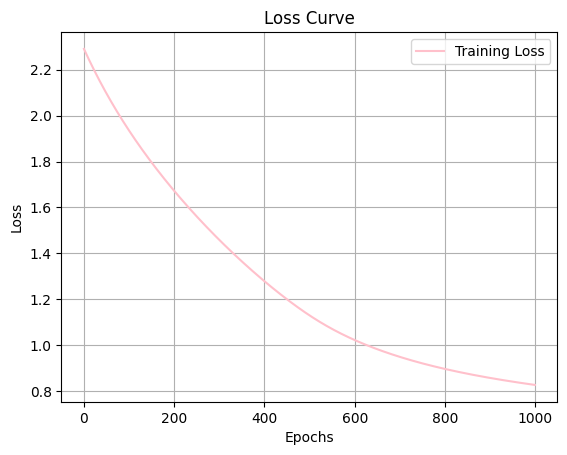

In [13]:
import matplotlib.pyplot as plt

train_features_np = train_features.to_numpy()  
train_labels_np = train_labels.to_numpy() 

# Softmax regression
W, b, loss_history = softmax_regression(train_features_np, train_labels_np, alpha=0.01, epochs=1000)

# Plot the loss curve
def plot_loss_curve(loss_history):
    """
    Plots the loss curve using the recorded loss history.

    Args:
    - loss_history (list): List of loss values over epochs.
    """
    plt.plot(loss_history, color='pink', label='Training Loss')
    plt.title('Loss Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_loss_curve(loss_history)


In [14]:
def predict(X, W, b):
    """
    Predict the class labels for new dataset points.
    
    Args:
    - X (numpy.ndarray): Feature matrix for new dataset (shape: (num_samples, num_features))
    - W (numpy.ndarray): Learned weights (shape: (num_features, num_classes))
    - b (numpy.ndarray): Learned biases (shape: (1, num_classes))
    
    Returns:
    - predictions (numpy.ndarray): Predicted class labels (shape: (num_samples,))
    """
    scores = np.dot(X, W) + b
    probs = softmax(scores)  
    return np.argmax(probs, axis=1) 

In [15]:
def test_predict():
    train_features = np.random.randn(100, 3)
    W = np.random.randn(3, 3)
    b = np.random.randn(1, 3)
    predictions = predict(train_features, W, b)
    assert predictions.shape[0] == train_features.shape[0], "Test failed: Prediction output size mismatch"
    print("test_predict passed!")
test_predict()

test_predict passed!


In [17]:
train_predictions = predict(train_features, W, b)
test_predictions = predict(test_features, W, b)

train_accuracy = accuracy_score(np.argmax(train_labels, axis=1), train_predictions)
test_accuracy = accuracy_score(np.argmax(test_labels, axis=1), test_predictions)

print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"Testing Accuracy: {test_accuracy * 100:.2f}%")

Training Accuracy: 64.04%
Testing Accuracy: 56.98%
